In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [6]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('project_files')

In [7]:
import os

for root, dirs, files in os.walk('project_files'):
    for file in files:
        print(os.path.join(root, file))

project_files/StudentsPerformance.csv


In [8]:
df = pd.read_csv('project_files/StudentsPerformance.csv')

In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('project_files/StudentsPerformance.csv')

In [12]:
df.shape

(1000, 8)

In [13]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [16]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [17]:
df["total_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

parent_edu = df.groupby(
    "parental level of education"
)["total_score"].mean().sort_values()

parent_edu

,total_score
parental level of education,
high school,189.290816
some high school,195.324022
some college,205.429204
associate's degree,208.707207
bachelor's degree,215.771186
master's degree,220.796610


In [18]:
df.groupby(
    "test preparation course"
)["total_score"].mean()

,total_score
test preparation course,
completed,218.008380
none,195.116822


In [19]:
corr = df[
    ["math score",
     "reading score",
     "writing score"]
].corr()

corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [20]:
df.groupby("gender")[
    ["math score",
     "reading score",
     "writing score"]
].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [21]:
df["total_score"].describe()

,total_score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


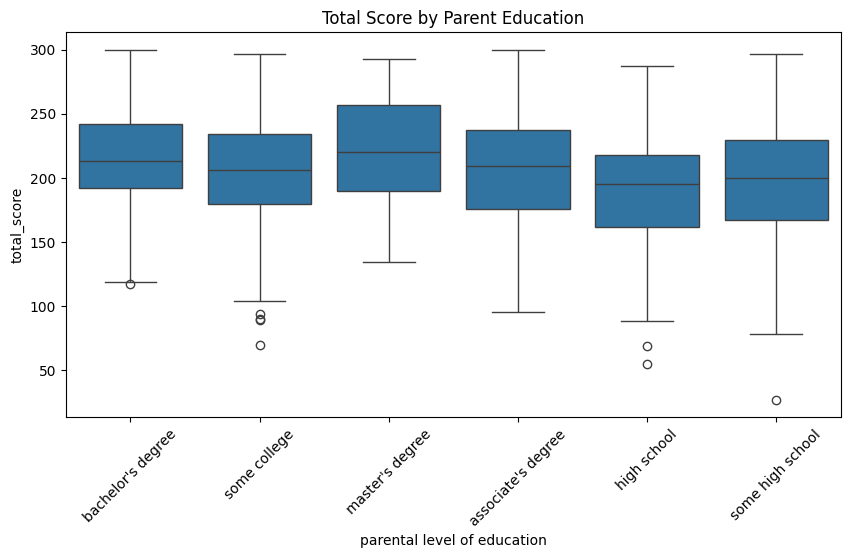

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="parental level of education",
    y="total_score",
    data=df
)
plt.title("Total Score by Parent Education")
plt.xticks(rotation=45)
plt.show()

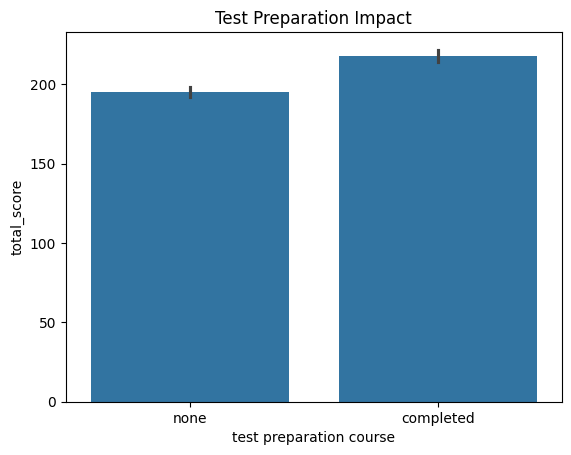

In [23]:
sns.barplot(
    x="test preparation course",
    y="total_score",
    data=df
)

plt.title("Test Preparation Impact")
plt.show()

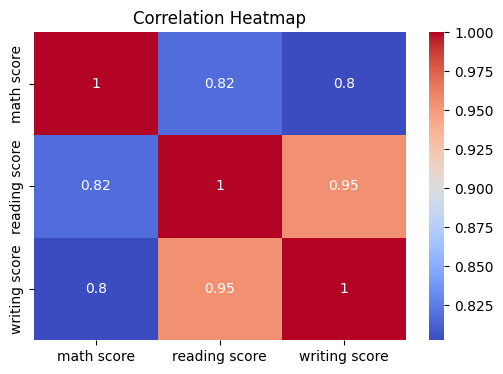

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

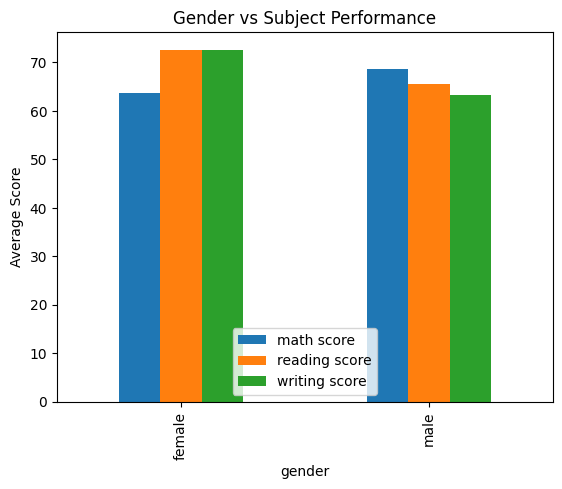

In [25]:
gender_scores = df.groupby("gender")[
    ["math score",
     "reading score",
     "writing score"]
].mean()

gender_scores.plot(kind="bar")

plt.title("Gender vs Subject Performance")
plt.ylabel("Average Score")
plt.show()

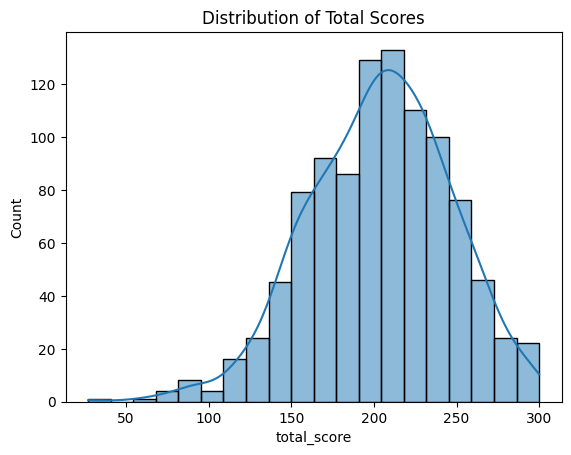

In [26]:
sns.histplot(
    df["total_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Scores")
plt.show()

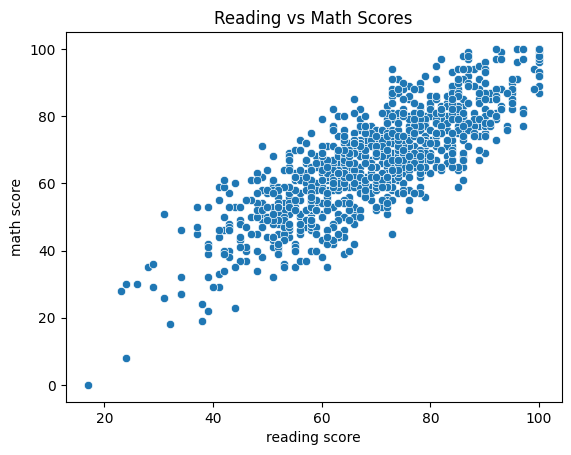

In [27]:
sns.scatterplot(
    x="reading score",
    y="math score",
    data=df
)

plt.title("Reading vs Math Scores")
plt.show()

In [28]:
df["at_risk"] = (
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
)

In [29]:
df["at_risk"].sum()

np.int64(188)

In [30]:
(df["at_risk"].mean()) * 100

np.float64(18.8)

In [31]:
df.groupby("gender")["at_risk"].mean()*100

,at_risk
gender,
female,17.181467
male,20.539419


In [32]:
df.groupby(
    "test preparation course"
)["at_risk"].mean()*100

,at_risk
test preparation course,
completed,10.055866
none,23.676012


# Principal's Report

## Executive Summary

The student performance dataset was analyzed to identify factors that influence academic achievement and to detect students at academic risk. The analysis showed that parental education level, test preparation, and gender have significant effects on student performance. Approximately 18.8% of students were identified as at-risk, indicating the need for targeted intervention programs.

## Key Findings

1. Students whose parents have higher education levels achieve better academic scores.

2. Students who completed the test preparation course scored significantly higher than students who did not complete it.

3. Reading and writing scores have a very strong positive correlation.

4. Male students perform better in mathematics, while female students perform better in reading and writing.

5. Around 18.8% of students were identified as at-risk because they scored below 50 in at least one subject.

## Recommendations

1. Expand test preparation programs for all students, especially low-performing students.

2. Provide additional tutoring and academic support for students identified as at-risk.

3. Increase parental involvement through workshops and communication programs to encourage academic support at home.

## Conclusion

The analysis indicates that educational support at home and participation in test preparation programs strongly influence student success. By focusing on at-risk students and expanding academic support initiatives, the school can improve overall performance and reduce failure risk in future academic years.

# Most Impactful Recommendation

The most impactful recommendation is expanding access to test preparation courses. Students who completed the course consistently achieved higher scores and had a lower percentage of at-risk cases. This intervention can be implemented at a relatively low cost while benefiting a large number of students. Increasing participation in test preparation programs is likely to improve overall academic performance across the school.